# Множественная линейная регрессия на чистых данных

**Цель работы:** познакомиться с основными приёмами работы с множественными регрессионными моделями с использованием библиотеки **sklearn**.

**Содержание работы:**
1. Загрузка датасета (признаки X и целевая переменная Y).
2. Количественное описание датасета: размеры, статистика по признакам.
3. Построение парных регрессий от каждого признака.
4. Построение модели множественной линейной регрессии и оценка её качества.

## 1. Импорт библиотек и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Загружаем датасет №0 (файлы с признаками `0_x.csv` и целевой переменной `0_y.csv`). Файлы не содержат заголовков, поэтому указываем `header=None`.

In [2]:
x = pd.read_csv(
    'https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_x.csv',
    header=None
)
y = pd.read_csv(
    'https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_y.csv',
    header=None
)

print('Первые 5 строк признаков X:')
display(x.head())
print('\nПервые 5 строк целевой переменной Y:')
display(y.head())

Первые 5 строк признаков X:


,0,1,2,3,4
0,0.071841,0.855352,-0.305597,0.028253,1.826895
1,0.139521,-0.423507,0.461059,-0.447400,-0.034988
2,1.626311,-0.257622,-0.697520,1.413219,1.086292
3,-1.183233,-0.826343,0.073047,-0.639690,-0.503273
4,-0.783365,-0.861232,0.951448,-0.117306,0.680597



Первые 5 строк целевой переменной Y:


,0
0,63.320498
1,-23.426394
2,11.982771
3,-102.883304
4,-49.373475


## 2. Описание датасета

In [3]:
print(f'Размер X: {x.shape}  (объекты × признаки)')
print(f'Размер Y: {y.shape}')
print(f'Количество точек данных: {x.shape[0]}')
print(f'Количество признаков: {x.shape[1]}')

Размер X: (387, 5)  (объекты × признаки)
Размер Y: (387, 1)
Количество точек данных: 387
Количество признаков: 5


Статистика по каждому признаку:

In [4]:
x.describe().round(2)

,0,1,2,3,4
count,387.00,387.00,387.00,387.00,387.00
mean,0.08,-0.02,-0.09,0.05,0.07
std,1.01,1.01,1.01,1.00,0.96
min,-2.72,-3.53,-2.95,-3.47,-2.38
25%,-0.51,-0.61,-0.73,-0.59,-0.58
50%,0.06,-0.01,-0.12,0.02,-0.03
75%,0.75,0.60,0.53,0.75,0.67
max,3.08,2.78,2.96,2.94,3.63


- В матрице признаков **X** 387 строк и 5 столбцов: 387 объектов с 5 признаками.
- В целевой переменной **Y** 387 строк и 1 столбец.
- Количество строк совпадает — данные готовы для машинного обучения.

## 3. Парная линейная регрессия (признак №1)

Для начала построим парную регрессию от одного признака (столбец с индексом 1). При передаче одного столбца в `sklearn` важно сохранить двумерную структуру: `x[[1]]` (DataFrame), а не `x[1]` (Series).

In [5]:
binary = LinearRegression()
binary.fit(x[[1]], y)

print(f'Коэффициент b1: {binary.coef_[0][0]:.4f}')
print(f'Свободный член b0: {binary.intercept_[0]:.4f}')
print(f'R² (коэффициент детерминации): {binary.score(x[[1]], y):.4f}')

Коэффициент b1: 95.5201
Свободный член b0: 0.0033
R² (коэффициент детерминации): 0.7700


### Визуализация парной регрессии

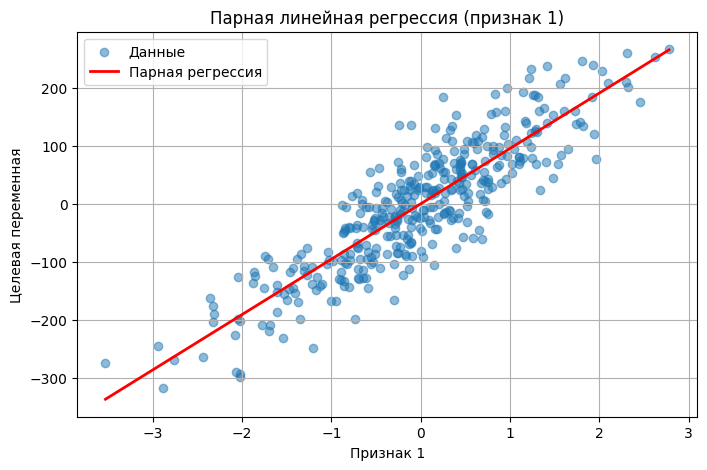

In [6]:
xx = np.linspace(x[1].min(), x[1].max(), 100).reshape((-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(x[1], y, alpha=0.5, label='Данные')
plt.plot(xx, binary.predict(xx), c='r', linewidth=2, label='Парная регрессия')
plt.xlabel('Признак 1')
plt.ylabel('Целевая переменная')
plt.title('Парная линейная регрессия (признак 1)')
plt.legend()
plt.grid(True)
plt.show()

R² ≈ 0.77 свидетельствует о средней точности модели: около 77% дисперсии целевой переменной объясняется данным признаком.

## 4. Построение парных регрессий для всех признаков

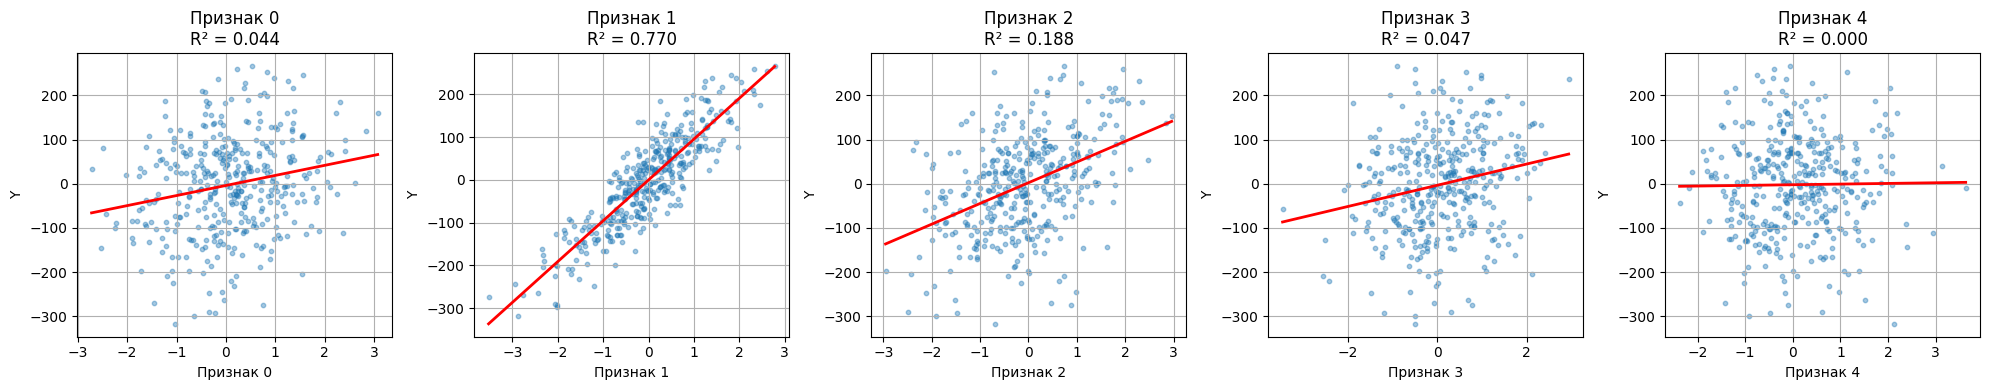

In [7]:
fig, axes = plt.subplots(1, x.shape[1], figsize=(20, 4))

for i in range(x.shape[1]):
    model = LinearRegression()
    model.fit(x[[i]], y)

    xx = np.linspace(x[i].min(), x[i].max(), 100).reshape((-1, 1))

    axes[i].scatter(x[i], y, alpha=0.4, s=10)
    axes[i].plot(xx, model.predict(xx), c='r', linewidth=2)
    axes[i].set_title(f'Признак {i}\nR² = {model.score(x[[i]], y):.3f}')
    axes[i].set_xlabel(f'Признак {i}')
    axes[i].set_ylabel('Y')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Каждый подграфик показывает связь одного признака с целевой переменной. Значение R² на каждом графике позволяет оценить, насколько сильно данный признак влияет на результат по отдельности.

## 5. Множественная линейная регрессия

Теперь построим модель, использующую **все 5 признаков** одновременно. Ожидается, что точность возрастёт, так как модель получает больше информации для предсказания.

In [8]:
multiple = LinearRegression()
multiple.fit(x, y)

print('Коэффициенты модели:')
for i, coef in enumerate(multiple.coef_[0]):
    print(f'  b{i+1} (признак {i}): {coef:.4f}')
print(f'\nСвободный член b0: {multiple.intercept_[0]:.4f}')
print(f'R² на обучающих данных: {multiple.score(x, y):.4f}')

Коэффициенты модели:
  b1 (признак 0): 15.7954
  b2 (признак 1): 93.2152
  b3 (признак 2): 37.1941
  b4 (признак 3): 31.1913
  b5 (признак 4): -0.2377

Свободный член b0: 0.5650
R² на обучающих данных: 0.9922


R² = 0.99 говорит о почти идеальной модели. Чем больше информации подаётся на вход модели машинного обучения, тем более точный результат можно ожидать (при условии отсутствия переобучения).

### Визуализация множественной регрессии: предсказанные vs. истинные значения

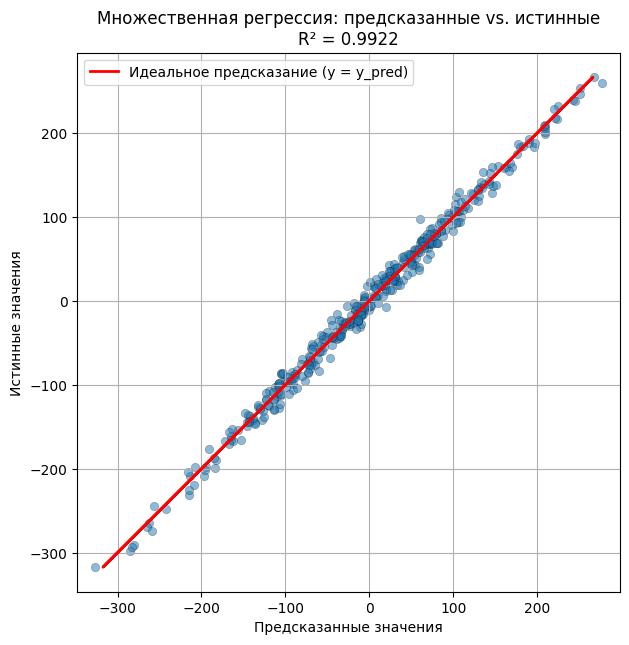

In [9]:
yy = multiple.predict(x)

plt.figure(figsize=(7, 7))
plt.scatter(yy, y, alpha=0.5, edgecolors='k', linewidths=0.3)
plt.plot(y, y, c='r', linewidth=2, label='Идеальное предсказание (y = y_pred)')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.title(f'Множественная регрессия: предсказанные vs. истинные\nR² = {multiple.score(x, y):.4f}')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

На графике точки плотно прилегают к диагонали `y = y_pred`, что подтверждает высокую точность множественной модели. Красная линия обозначает идеальное предсказание.

## Выводы

1. Загружен и проанализирован датасет: 387 объектов, 5 признаков, пропусков нет.
2. Построены парные регрессии для каждого признака — все дают умеренную точность (R² ниже, чем у множественной модели).
3. Множественная линейная регрессия достигла R² ≈ 0.99, что говорит о высокой предсказательной способности модели.
4. Визуализация «предсказанные vs. истинные» подтверждает качество модели — точки лежат близко к диагонали.